<a href="https://colab.research.google.com/github/svanshika-afk/tinyML-lab-2548544/blob/lab1/TinyML_LAB1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
trial1 = pd.read_csv("trial1.csv")
trial2 = pd.read_csv("trial2.csv")
trial3 = pd.read_csv("trial3.csv")
trial4 = pd.read_csv("trial4.csv")

In [5]:
print("Trial 1:")
display(trial1.head())

print("Shape:", trial1.shape)
print("Columns:", trial1.columns.tolist())

Trial 1:


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,-0.000080,0.268675,0.057523,0.014589,0.275151
1,0.009933,0.290836,0.073876,0.003429,0.300092
2,0.019946,0.226382,0.067776,-0.015617,0.236826
3,0.029959,0.115944,0.021788,-0.025444,0.120686
4,0.039972,-0.011559,-0.033869,-0.019430,0.040721


Shape: (1514, 5)
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']


In [6]:
print("Trial 2:", trial2.shape)
print("Trial 3:", trial3.shape)
print("Trial 4:", trial4.shape)

Trial 2: (2058, 5)
Trial 3: (1956, 5)
Trial 4: (794, 5)


In [7]:
for i, trial in enumerate([trial1, trial2, trial3, trial4], start=1):
    print(f"\n--- Trial {i} ---")

    print("Columns:", trial.columns.tolist())
    print("Number of samples:", len(trial))
    print("Start time:", trial["Time (s)"].iloc[0])
    print("End time:", trial["Time (s)"].iloc[-1])

    # Check average time difference between samples
    time_diff = trial["Time (s)"].diff().dropna()
    print("Average sampling interval:", time_diff.mean(), "seconds")
    print("Approx. sampling rate:", 1 / time_diff.mean(), "Hz")


--- Trial 1 ---
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']
Number of samples: 1514
Start time: -8.045833238e-05
End time: 15.14947913
Average sampling interval: 0.010012927685612941 seconds
Approx. sampling rate: 99.87089005315083 Hz

--- Trial 2 ---
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']
Number of samples: 2058
Start time: 0.0007008333341
End time: 20.59730154
Average sampling interval: 0.010012931797115168 seconds
Approx. sampling rate: 99.87084904424403 Hz

--- Trial 3 ---
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']
Number of samples: 1956
Start time: 0.001090083337
End time: 19.57777333
Average sampling interval: 0.010013648719520717 seconds
Approx. sampling rate: 99.8636988384253 Hz

--- Trial 4 ---
Columns: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope

In [8]:
# Add trial number to each dataset
trial1["trial"] = 1
trial2["trial"] = 2
trial3["trial"] = 3
trial4["trial"] = 4

# Combine all four trials
df = pd.concat(
    [trial1, trial2, trial3, trial4],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (6322, 6)


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s),trial
0,-0.000080,0.268675,0.057523,0.014589,0.275151,1
1,0.009933,0.290836,0.073876,0.003429,0.300092,1
2,0.019946,0.226382,0.067776,-0.015617,0.236826,1
3,0.029959,0.115944,0.021788,-0.025444,0.120686,1
4,0.039972,-0.011559,-0.033869,-0.019430,0.040721,1


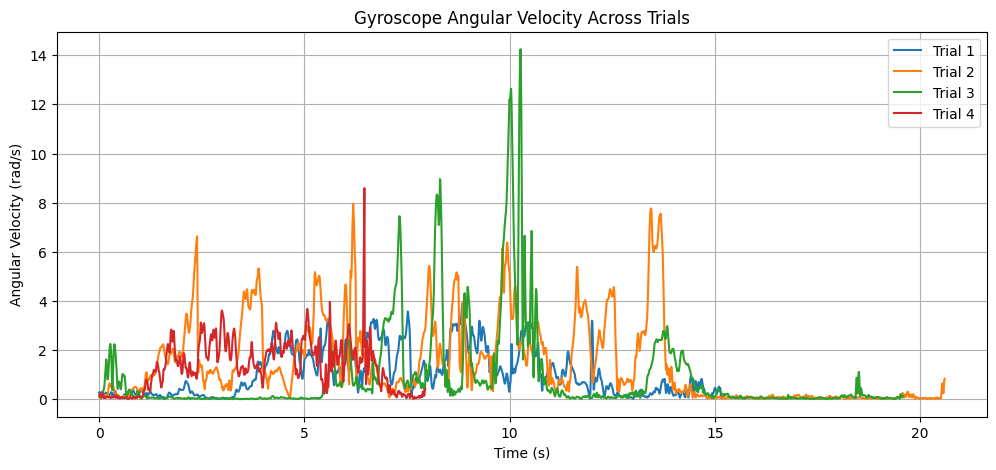

In [9]:
plt.figure(figsize=(12, 5))

for trial_no in [1, 2, 3, 4]:
    trial_data = df[df["trial"] == trial_no]

    plt.plot(
        trial_data["Time (s)"],
        trial_data["Absolute (rad/s)"],
        label=f"Trial {trial_no}"
    )

plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Gyroscope Angular Velocity Across Trials")
plt.legend()
plt.grid(True)

plt.show()

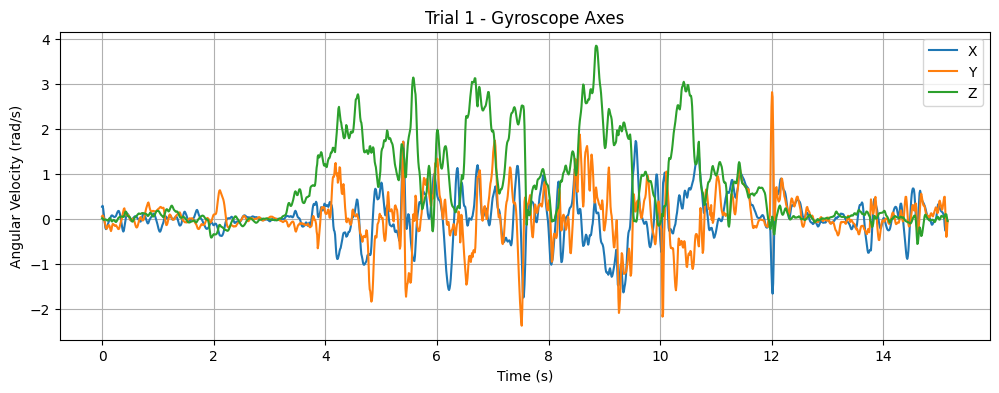

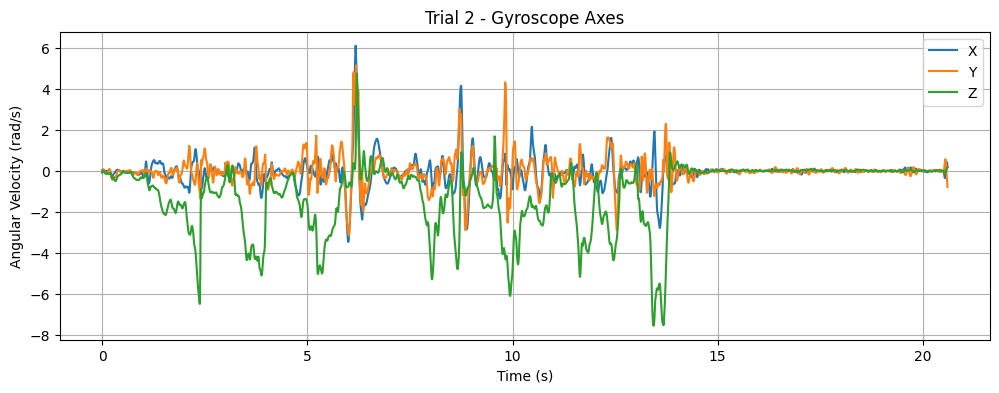

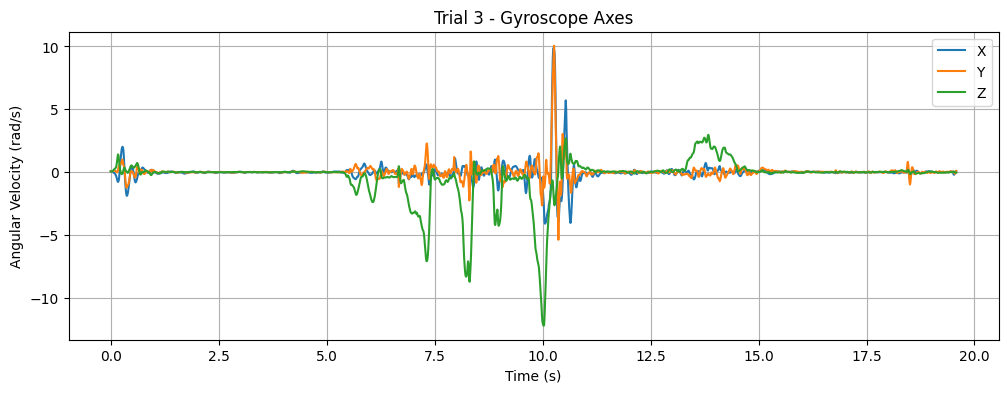

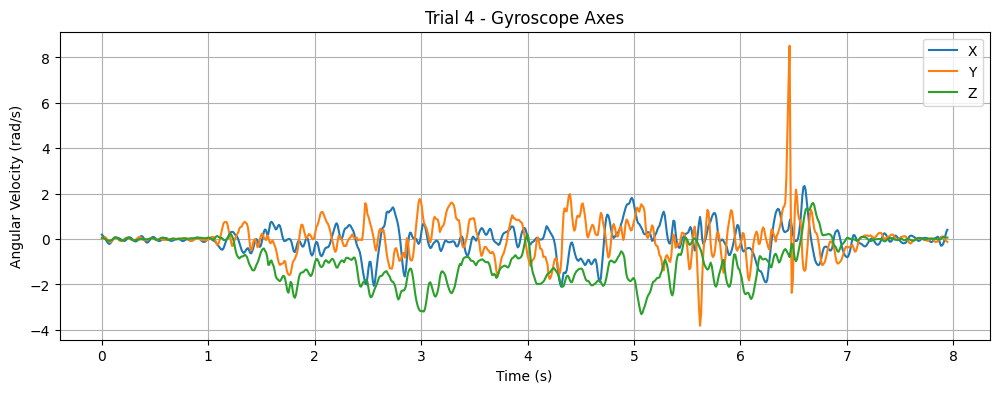

In [10]:
for trial_no in [1, 2, 3, 4]:

    trial_data = df[df["trial"] == trial_no]

    plt.figure(figsize=(12, 4))

    plt.plot(
        trial_data["Time (s)"],
        trial_data["Gyroscope x (rad/s)"],
        label="X"
    )

    plt.plot(
        trial_data["Time (s)"],
        trial_data["Gyroscope y (rad/s)"],
        label="Y"
    )

    plt.plot(
        trial_data["Time (s)"],
        trial_data["Gyroscope z (rad/s)"],
        label="Z"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Angular Velocity (rad/s)")
    plt.title(f"Trial {trial_no} - Gyroscope Axes")
    plt.legend()
    plt.grid(True)

    plt.show()

In [11]:
WINDOW_SIZE = 100   # 1 second at ~100 Hz
STEP_SIZE = 50     # 50% overlap

windows = []

for trial_no in [1, 2, 3, 4]:

    trial_data = df[df["trial"] == trial_no].reset_index(drop=True)

    for start in range(0, len(trial_data) - WINDOW_SIZE + 1, STEP_SIZE):

        window = trial_data.iloc[start:start + WINDOW_SIZE]

        windows.append({
            "trial": trial_no,
            "start_time": window["Time (s)"].iloc[0],
            "end_time": window["Time (s)"].iloc[-1],
            "gyro_mean": window["Absolute (rad/s)"].mean(),
            "gyro_std": window["Absolute (rad/s)"].std(),
            "gyro_max": window["Absolute (rad/s)"].max(),
            "gyro_rms": np.sqrt(
                np.mean(window["Absolute (rad/s)"] ** 2)
            )
        })

features_df = pd.DataFrame(windows)

print("Number of windows:", len(features_df))
display(features_df.head())

Number of windows: 121


,trial,start_time,end_time,gyro_mean,gyro_std,gyro_max,gyro_rms
0,1,-0.000080,0.991201,0.191923,0.079968,0.381667,0.207763
1,1,0.500567,1.491848,0.202049,0.086540,0.403541,0.219632
2,1,1.001214,1.992495,0.206396,0.095848,0.426185,0.227364
3,1,1.501861,2.493143,0.263926,0.174826,0.748647,0.316094
4,1,2.002508,2.993791,0.202550,0.197714,0.748647,0.282358


In [12]:
print(features_df["gyro_mean"].describe())

count    121.000000
mean       1.209330
std        1.089319
min        0.025109
25%        0.149210
50%        1.131864
75%        1.988868
max        5.359649
Name: gyro_mean, dtype: float64


In [13]:
# Provisional threshold based on the median gyro_mean
threshold = features_df["gyro_mean"].median()

# Create labels
features_df["label"] = (
    features_df["gyro_mean"] >= threshold
).astype(int)

print("Provisional threshold:", threshold, "rad/s")

print("\nLabel distribution:")
print(features_df["label"].value_counts())

display(features_df.head(10))

Provisional threshold: 1.13186355377 rad/s

Label distribution:
label
1    61
0    60
Name: count, dtype: int64


,trial,start_time,end_time,gyro_mean,gyro_std,gyro_max,gyro_rms,label
0,1,-0.000080,0.991201,0.191923,0.079968,0.381667,0.207763,0
1,1,0.500567,1.491848,0.202049,0.086540,0.403541,0.219632,0
2,1,1.001214,1.992495,0.206396,0.095848,0.426185,0.227364,0
3,1,1.501861,2.493143,0.263926,0.174826,0.748647,0.316094,0
4,1,2.002508,2.993791,0.202550,0.197714,0.748647,0.282358,0
5,1,2.503156,3.494439,0.136339,0.165150,0.692030,0.213518,0
6,1,3.003804,3.995086,0.534779,0.453549,1.536560,0.699741,0
7,1,3.504452,4.495734,1.392209,0.662692,2.792925,1.540460,1
8,1,4.005099,4.996381,1.943273,0.481933,2.792925,2.001562,1
9,1,4.505747,5.497028,1.839868,0.493697,2.883230,1.904314,1


In [14]:
from sklearn.model_selection import train_test_split

# Features
X = features_df[
    ["gyro_mean", "gyro_std", "gyro_max", "gyro_rms"]
]

# Target labels
y = features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (121, 4)
y shape: (121,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training samples: 96
Testing samples: 25

Training labels:
label
1    48
0    48
Name: count, dtype: int64

Testing labels:
label
1    13
0    12
Name: count, dtype: int64


In [16]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.6053 - loss: 0.5254 - val_accuracy: 0.4500 - val_loss: 0.6080
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6842 - loss: 0.4916 - val_accuracy: 0.6000 - val_loss: 0.5930
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7237 - loss: 0.4702 - val_accuracy: 0.7000 - val_loss: 0.5791
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7368 - loss: 0.4550 - val_accuracy: 0.7000 - val_loss: 0.5670
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7632 - loss: 0.4436 - val_accuracy: 0.7500 - val_loss: 0.5557
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7763 - loss: 0.4345 - val_accuracy: 0.7500 - val_loss: 0.5444
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7763 - loss: 0.4258 - val_accuracy: 0.8500 - val_loss: 0.5340
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8026 - loss: 0.4179 - val_accuracy: 0.8500 - val_loss: 0.5238

In [18]:
# Evaluate the model on completely unseen test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.2763771414756775
Test Accuracy: 0.8799999952316284


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predicted probabilities
y_pred_prob = model.predict(X_test, verbose=0)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["SAFE", "UNSAFE"]
))

Confusion Matrix:
[[ 9  3]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        SAFE       1.00      0.75      0.86        12
      UNSAFE       0.81      1.00      0.90        13

    accuracy                           0.88        25
   macro avg       0.91      0.88      0.88        25
weighted avg       0.90      0.88      0.88        25



In [20]:
model.save("payload_safety_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [21]:
# Convert the trained Keras model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

# Save the TFLite model
with open("payload_safety_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully!")

Saved artifact at '/tmp/tmpi5suqeqi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135249996291088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996291664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292816: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model created successfully!


In [22]:
import os

size_kb = os.path.getsize("payload_safety_model.tflite") / 1024

print(f"TFLite model size: {size_kb:.2f} KB")

TFLite model size: 2.89 KB


In [23]:
def representative_dataset():
    for sample in X_train.values.astype(np.float32):
        sample = sample.reshape(1, 4)
        yield [sample]

In [24]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide representative data
converter.representative_dataset = representative_dataset

# Force full integer quantization
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# Force INT8 input and output
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_int8_model = converter.convert()

# Save
with open("payload_safety_model_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("INT8 TFLite model created successfully!")

Saved artifact at '/tmp/tmpsk05qstw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135249996291088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996291664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249996292816: TensorSpec(shape=(), dtype=tf.resource, name=None)
INT8 TFLite model created successfully!


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [25]:
size_kb = os.path.getsize(
    "payload_safety_model_int8.tflite"
) / 1024

print(f"INT8 TFLite model size: {size_kb:.2f} KB")

INT8 TFLite model size: 3.17 KB


In [26]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="payload_safety_model_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT DETAILS:")
print(input_details)

print("\nOUTPUT DETAILS:")
print(output_details)

INPUT DETAILS:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.05585471913218498, -128), 'quantization_parameters': {'scales': array([0.05585472], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

OUTPUT DETAILS:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [27]:
# Get one test sample
sample = X_test.iloc[0].values.astype(np.float32).reshape(1, -1)

# Get quantization parameters
input_scale = input_details[0]["quantization"][0]
input_zero_point = input_details[0]["quantization"][1]

output_scale = output_details[0]["quantization"][0]
output_zero_point = output_details[0]["quantization"][1]

# Convert float input to INT8
sample_int8 = np.round(
    sample / input_scale + input_zero_point
).astype(np.int8)

# Give input to TFLite model
interpreter.set_tensor(
    input_details[0]["index"],
    sample_int8
)

# Run inference
interpreter.invoke()

# Get INT8 output
output_int8 = interpreter.get_tensor(
    output_details[0]["index"]
)

# Convert output back to normal probability
prediction_probability = (
    output_int8.astype(np.float32) - output_zero_point
) * output_scale

# Convert probability to class
prediction = int(prediction_probability[0][0] >= 0.5)

print("TFLite INT8 output:", output_int8)
print("Prediction probability:", prediction_probability[0][0])
print("Predicted class:", prediction)
print("Actual class:", y_test.iloc[0])

TFLite INT8 output: [[-47]]
Prediction probability: 0.31640625
Predicted class: 0
Actual class: 0


In [28]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tflite_predictions = []

for i in range(len(X_test)):

    # Get test sample
    sample = X_test.iloc[i].values.astype(np.float32).reshape(1, -1)

    # Convert FLOAT → INT8
    sample_int8 = np.round(
        sample / input_scale + input_zero_point
    ).astype(np.int8)

    # Set input
    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    # Run model
    interpreter.invoke()

    # Get INT8 output
    output_int8 = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Convert INT8 output → probability
    probability = (
        output_int8.astype(np.float32) - output_zero_point
    ) * output_scale

    # SAFE = 0, UNSAFE = 1
    prediction = int(probability[0][0] >= 0.5)

    tflite_predictions.append(prediction)


# Convert to numpy array
tflite_predictions = np.array(tflite_predictions)

# Calculate accuracy
tflite_accuracy = accuracy_score(
    y_test,
    tflite_predictions
)

print("TFLite INT8 Accuracy:", f"{tflite_accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tflite_predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tflite_predictions,
        target_names=["SAFE", "UNSAFE"]
    )
)

TFLite INT8 Accuracy: 88.00%

Confusion Matrix:
[[ 9  3]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        SAFE       1.00      0.75      0.86        12
      UNSAFE       0.81      1.00      0.90        13

    accuracy                           0.88        25
   macro avg       0.91      0.88      0.88        25
weighted avg       0.90      0.88      0.88        25



In [29]:
# Read the INT8 TFLite model
with open("payload_safety_model_int8.tflite", "rb") as f:
    model_data = f.read()

# Create header file
with open("payload_safety_model.h", "w") as f:

    f.write("#ifndef PAYLOAD_SAFETY_MODEL_H\n")
    f.write("#define PAYLOAD_SAFETY_MODEL_H\n\n")

    f.write("const unsigned char payload_safety_model[] = {\n")

    # Write model bytes
    for i in range(0, len(model_data), 12):
        chunk = model_data[i:i+12]
        values = ", ".join(f"0x{byte:02x}" for byte in chunk)
        f.write("  " + values + ",\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int payload_safety_model_len = {len(model_data)};\n\n"
    )

    f.write("#endif\n")

print("Header file created successfully!")
print(f"Model size: {len(model_data)} bytes")


Header file created successfully!
Model size: 3248 bytes


In [30]:
import os

print("File exists:", os.path.exists("payload_safety_model.h"))
print("Header file size:",
      os.path.getsize("payload_safety_model.h"), "bytes")

File exists: True
Header file size: 20204 bytes
